## PyTorch Computer Vision

In [ ]:
import torch
from torch import nn

In [ ]:
import torchvision
import matplotlib.pyplot as plt

In [ ]:
print(torch.__version__, torchvision.__version__)

2.9.0+cu126 0.24.0+cu126


In [ ]:
# Getting a dataset
from pathlib import Path
datasets_path = Path('datasets')
fashion_path = datasets_path / 'fashion_data'

train_data = torchvision.datasets.FashionMNIST(
  root=fashion_path,
  train=True,
  download=True,
  transform=torchvision.transforms.ToTensor(),
  target_transform=None
)

test_data = torchvision.datasets.FashionMNIST(
    root=fashion_path,
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 312kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.7MB/s]


In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
image, label = train_data[0]
print(image, label)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [ ]:
# Check the shape of our image
print(f'Image shape: {image.shape} -> [color_channels, height, width]')
print(f'Image label: {class_names[label]}')

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image label: Ankle boot


## Visualizing our data

In [ ]:
import matplotlib.pyplot as plt

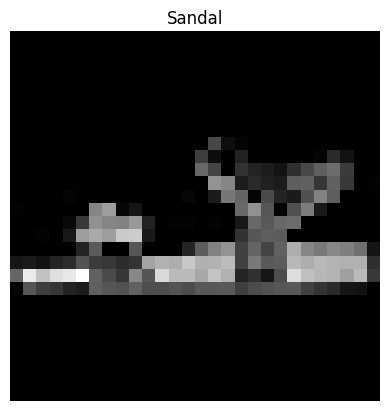

In [ ]:
image, label = train_data[-1]
plt.title(class_names[label])
plt.axis(False)
plt.imshow(image.squeeze(), cmap='gray')

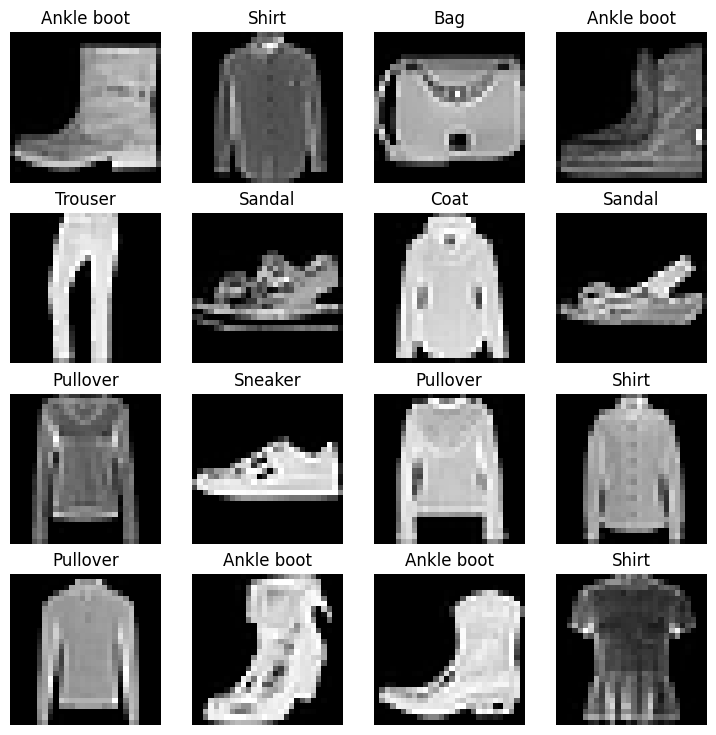

In [ ]:
# Plotting random images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
  random_index = torch.randint(0, len(train_data), (1,)).item()
  image, label = train_data[random_index]

  fig.add_subplot(rows, cols, i)

  plt.title(class_names[label])
  plt.axis(False)
  plt.imshow(image.squeeze(), cmap='gray')



## Mini-Batches

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7ab2854097f0>,
 <torch.utils.data.dataloader.DataLoader at 0x7ab285713d10>)

In [ ]:
print(f'Train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}')
print(f'Test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}')

Train dataloader: 1875 batches of 32
Test dataloader: 313 batches of 32


In [ ]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
test_features_batch, test_labels_batch = next(iter(test_dataloader))

train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [ ]:
# Show a sample
random_index = torch.randint(0, len(train_features_batch), size=(1,)).item()
image, label = train_features_batch[random_index], train_labels_batch[random_index]

image.squeeze()[:2], label.item()

(tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.5882, 0.4706, 0.4706, 0.4667, 0.4588, 0.4588, 0.4588, 0.4471,
          0.5490, 0.0039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.4000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 0.4039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000]]),
 1)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

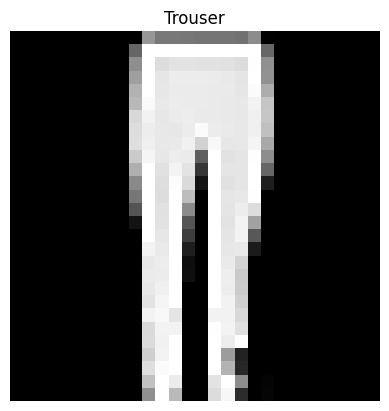

In [ ]:
# Plot the sample
plt.imshow(image.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.axis('off')

## Building a baseline model

In [ ]:
from torch import nn

class FashionMNISTModelV0(nn.Module):
  def __init__(
      self,
      input_shape: int,
      output_shape: int,
      device: torch.device,
      hidden_units = 64
    ):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

    self.to(device)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_stack(x)

In [ ]:
model_0 = FashionMNISTModelV0(
    input_shape=28*28, # the Flatten layer transform the shape: [color_channels, height, width] -> [color_channels, height * width]
    output_shape=len(class_names),
    device=device,
    hidden_units=64
)

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
dummy_x = torch.rand([1, 1, 28, 28]).to(device)
dummy_x.shape

torch.Size([1, 1, 28, 28])

In [ ]:
model_0.to(device)
model_0(dummy_x)

tensor([[-0.1602, -0.2753,  0.3467, -0.0388,  0.0371,  0.1028, -0.2970, -0.1120,
         -0.5459,  0.0470]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0237, -0.0282, -0.0165,  ..., -0.0111, -0.0272,  0.0052],
                      [ 0.0173,  0.0309, -0.0218,  ...,  0.0097,  0.0272, -0.0169],
                      [ 0.0213,  0.0087, -0.0238,  ..., -0.0287, -0.0115, -0.0096],
                      ...,
                      [-0.0063, -0.0213, -0.0171,  ...,  0.0317,  0.0034,  0.0034],
                      [-0.0096, -0.0054,  0.0004,  ..., -0.0351,  0.0025, -0.0079],
                      [-0.0158,  0.0117,  0.0340,  ..., -0.0312, -0.0063,  0.0351]],
                     device='cuda:0')),
             ('layer_stack.1.bias',
              tensor([ 0.0275,  0.0032, -0.0267,  0.0088, -0.0202, -0.0316, -0.0179, -0.0264,
                       0.0176, -0.0301, -0.0060,  0.0041, -0.0188, -0.0167,  0.0152, -0.0279,
                       0.0194, -0.0098, -0.0282, -0.0013, -0.0069,  0.0010, -0.0104,  0.0054,
                       0.0125,  0.0235, -0.0174,  0.0107,  0.0283, -0.00

In [ ]:
# Setting up a loss function, optimizer and an evaluation metric
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 16.1 MB/s eta 0:00:00


In [ ]:
from torchmetrics import Accuracy

accuracy_fn = Accuracy('multiclass', num_classes=len(class_names)).to(device)
# how to use: acc = accuracy_fn(predictions, targets)

In [ ]:
def print_execution_time(
    model: nn.Module,
    execution_fn,
    device: torch.device = None
):
  model = model.to(device)

  # Warm-up
  print("Warming-up")
  for _ in range(1):
    execution_fn()
  print("Finished Warming-up")

  if device.type == "cuda":
    torch.cuda.synchronize()

  if device.type == "cpu":
    import time

    # Measurement
    start_time = time.perf_counter()
    execution_fn()
    end_time = time.perf_counter()

    print(f"Inference time on {device}: {(end_time - start_time) * 1000:.4f} ms")

  elif device.type == "cuda":
    # Creating CUDA events
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    # Measurement
    start_event.record()
    execution_fn()
    end_event.record()

    # Wait for GPU to finish all the tasks
    torch.cuda.synchronize()

    print(f"Inference time on {device}: {start_event.elapsed_time(end_event):.4f} ms")

In [ ]:
from tqdm.auto import tqdm # Useful for progress bar display
def training_testing_batched_data(epochs: int = 3):
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = 0, 0
    accuracy_fn.reset()

    for batch, (X, y) in enumerate(train_dataloader):
      ## Training
      model_0.train()

      # Move data to target device
      X, y = X.to(device), y.to(device)

      # Forward pass
      y_logits = model_0(X)

      # Calculate the loss
      loss = loss_fn(y_logits, y)
      train_loss += loss.item()

      # Update Accuracy Metric
      accuracy_fn.update(y_logits, y)

      # Zero Grad
      optimizer.zero_grad()

      # Backpropagation
      loss.backward()

      # Optimizer step
      optimizer.step()

      if batch % 400 == 0:
        print(f"Batch {batch}, {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)
    train_acc = accuracy_fn.compute()

    test_loss, test_acc = 0, 0
    accuracy_fn.reset()

    ## Testing
    model_0.eval()
    with torch.inference_mode():
      for X_test, y_test in tqdm(test_dataloader):
        # Move data to target device
        X_test, y_test = X_test.to(device), y_test.to(device)

        test_logits = model_0(X_test)

        test_loss += loss_fn(test_logits, y_test).item()

        accuracy_fn.update(test_logits, y_test)

    test_loss /= len(test_dataloader)
    test_acc = accuracy_fn.compute()

    print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc * 100:.2f}%")

In [ ]:
# Executing our Loop and measuring the time
print_execution_time(model_0, lambda: training_testing_batched_data(3), device=torch.device(device))

Warming-up


  0%|          | 0/3 [00:00<?, ?it/s]

Batch 0, 0/60000 samples
Batch 400, 12800/60000 samples
Batch 800, 25600/60000 samples
Batch 1200, 38400/60000 samples
Batch 1600, 51200/60000 samples


  0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 0.8531 | Train Acc: 72.22% | Test Loss: 0.6171 | Test Acc: 78.81%
Batch 0, 0/60000 samples
Batch 400, 12800/60000 samples
Batch 800, 25600/60000 samples
Batch 1200, 38400/60000 samples
Batch 1600, 51200/60000 samples


...

Epoch: 0 | Train Loss: 0.4703 | Train Acc: 83.81% | Test Loss: 0.4925 | Test Acc: 82.53%
Batch 0, 0/60000 samples
Batch 400, 12800/60000 samples
Batch 800, 25600/60000 samples
Batch 1200, 38400/60000 samples
Batch 1600, 51200/60000 samples


  0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 1 | Train Loss: 0.4543 | Train Acc: 84.24% | Test Loss: 0.4823 | Test Acc: 82.71%
Batch 0, 0/60000 samples
Batch 400, 12800/60000 samples
Batch 800, 25600/60000 samples
Batch 1200, 38400/60000 samples
Batch 1600, 51200/60000 samples


  0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 2 | Train Loss: 0.4430 | Train Acc: 84.66% | Test Loss: 0.4677 | Test Acc: 83.40%
Inference time on cuda: 29574.7734 ms


In [ ]:
torch.manual_seed(42)

def eval_model(
    model: nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: nn.Module,
    accuracy_fn: Accuracy,
    device: torch.device
):
  """Returns a dictionary containing the result of the model predicting on dataloader"""
  loss, acc = 0, 0

  accuracy_fn = accuracy_fn.to(device)
  model = model.to(device)

  accuracy_fn.reset()

  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X = X.to(device)
      y = y.to(device)
      y_logits = model(X)

      loss += loss_fn(y_logits, y).item()
      accuracy_fn.update(y_logits, y)

  loss /= len(data_loader)
  acc = accuracy_fn.compute()

  return {
      "model_name": model.__class__.__name__,
      "model_loss": loss,
      "model_accuracy": acc.item()
  }


In [ ]:
model_0_results = eval_model(
    model=model_0,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4676585056530401,
 'model_accuracy': 0.8339999914169312}

## Improving our model through experimentation

In [ ]:
from dataclasses import dataclass

@dataclass
class Config:
  device: torch.device
  epochs: int = 10
  learning_rate: float = 0.001

config = Config(
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
)


In [ ]:
class FashionMNISTModelV1(nn.Module):
  def __init__(
      self,
      input_shape: int,
      output_shape: int,
      hidden_units: int,
      device: torch.device
  ):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

    self.to(device)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_stack(x)

In [ ]:
data_shape = train_data.data.shape
input_shape = data_shape[-2] * data_shape[-1]

output_shape = len(train_data.classes)

torch.manual_seed(42)

model_1 = FashionMNISTModelV1(
    input_shape,
    output_shape,
    hidden_units=128,
    device=config.device
)

model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=config.learning_rate)

## Defining a training function

In [ ]:
from typing import Callable

def train_step(
    model: nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn: Accuracy,
    device: torch.device,
    epochs: int
):
  model = model.to(device)
  accuracy_fn = accuracy_fn.to(device)

  model.train()

  for epoch in tqdm(range(epochs)):
    train_loss = 0
    accuracy_fn.reset()

    for X, y in data_loader:
      X = X.to(device)
      y = y.to(device)

      y_logits = model(X)

      loss = loss_fn(y_logits, y)
      train_loss += loss.item()
      accuracy_fn.update(y_logits, y)

      optimizer.zero_grad()

      loss.backward()

      optimizer.step()

    average_loss = train_loss / len(data_loader)
    acc = accuracy_fn.compute().item()

    print(f'Epoch: {epoch} | Train Loss: {average_loss} | Train Accuracy: {acc * 100:.2f}%')


In [ ]:
train_step(
    model=model_1,
    data_loader=train_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    accuracy_fn=accuracy_fn,
    device=config.device,
    epochs=config.epochs
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 0.5194165867884953 | Train Accuracy: 81.21%
Epoch: 1 | Train Loss: 0.3760475900570552 | Train Accuracy: 86.20%
Epoch: 2 | Train Loss: 0.33965544109741846 | Train Accuracy: 87.47%
Epoch: 3 | Train Loss: 0.31728660127222535 | Train Accuracy: 88.20%
Epoch: 4 | Train Loss: 0.29761902233759563 | Train Accuracy: 88.94%
Epoch: 5 | Train Loss: 0.28219478335678577 | Train Accuracy: 89.45%
Epoch: 6 | Train Loss: 0.2695190447231134 | Train Accuracy: 89.86%
Epoch: 7 | Train Loss: 0.25875239883263906 | Train Accuracy: 90.20%
Epoch: 8 | Train Loss: 0.24900724478761355 | Train Accuracy: 90.60%
Epoch: 9 | Train Loss: 0.23844580500821272 | Train Accuracy: 90.89%


In [ ]:
model_1_results = eval_model(
    model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=config.device
)

model_0_results, model_1_results

({'model_name': 'FashionMNISTModelV0',
  'model_loss': 0.4676585056530401,
  'model_accuracy': 0.8339999914169312},
 {'model_name': 'FashionMNISTModelV1',
  'model_loss': 0.3457784860516889,
  'model_accuracy': 0.880299985408783})

## Building a Convolutional Neural Network (CNN)

In [ ]:
class FashionMNISTModelV2(nn.Module):
  """
  Model architecture that replicates the TinyVGG
  """
  def __init__(self, input_shape, output_shape, hidden_units, device: torch.device):
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

    self.to(device)

  def forward(self, x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x


In [ ]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(
    input_shape=1, # number of color_channels
    output_shape=len(class_names), # number of classes
    hidden_units=32,
    device=config.device
)
model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=10, bias=True)
  )
)

## Understanding the nn.Conv2d() layer

In [ ]:
torch.manual_seed(42)

# Creates a Batch of images
images = torch.randn(size=(32, 3, 64, 64), device=config.device)
test_image = images[torch.randint(0, len(images), size=(1,)).item()]

conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=(3, 3), # Equivalente to set just 3
    stride=1,
    padding=1,
    device=config.device
)

output_conv = conv_layer(test_image)
print(test_image.shape, output_conv.shape)

torch.Size([3, 64, 64]) torch.Size([10, 64, 64])


## Understanding the nn.MaxPool2d() layer

In [ ]:
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Passing the output_conv through the conv layer
output_conv_pool = max_pool_layer(output_conv)
output_conv_pool.shape

torch.Size([10, 32, 32])

## Testing our model with a random image

In [ ]:
random_image = torch.randn(size=(1, 28, 28), device=config.device)
output = model_2(random_image.unsqueeze(0))
output

tensor([[-0.0484,  0.0055,  0.0315,  0.0262, -0.0007,  0.0082,  0.0719, -0.0295,
          0.0734, -0.1015]], device='cuda:0', grad_fn=<AddmmBackward0>)

## Setting up a loss function and an optimizer for our CNN Model

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.05)

## Training our model

In [ ]:
train_step(
    model=model_2,
    data_loader=train_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    accuracy_fn=accuracy_fn,
    device=config.device,
    epochs=5
)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 0.5888145063598951 | Train Accuracy: 78.61%
Epoch: 1 | Train Loss: 0.33503741918404895 | Train Accuracy: 87.95%
Epoch: 2 | Train Loss: 0.293207868351539 | Train Accuracy: 89.47%
Epoch: 3 | Train Loss: 0.2661421960125367 | Train Accuracy: 90.42%
Epoch: 4 | Train Loss: 0.2478443184196949 | Train Accuracy: 91.07%


##Evaluating our model

In [ ]:
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=config.device
)

model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.27717001995625207,
 'model_accuracy': 0.899399995803833}

## Comparing our results

In [ ]:
import pandas as pd

results_df = pd.DataFrame([model_0_results, model_1_results, model_2_results])
results_df

,model_name,model_loss,model_accuracy
0,FashionMNISTModelV0,0.467659,0.8340
1,FashionMNISTModelV1,0.345778,0.8803
2,FashionMNISTModelV2,0.229222,0.9172


## Visualizing our model results

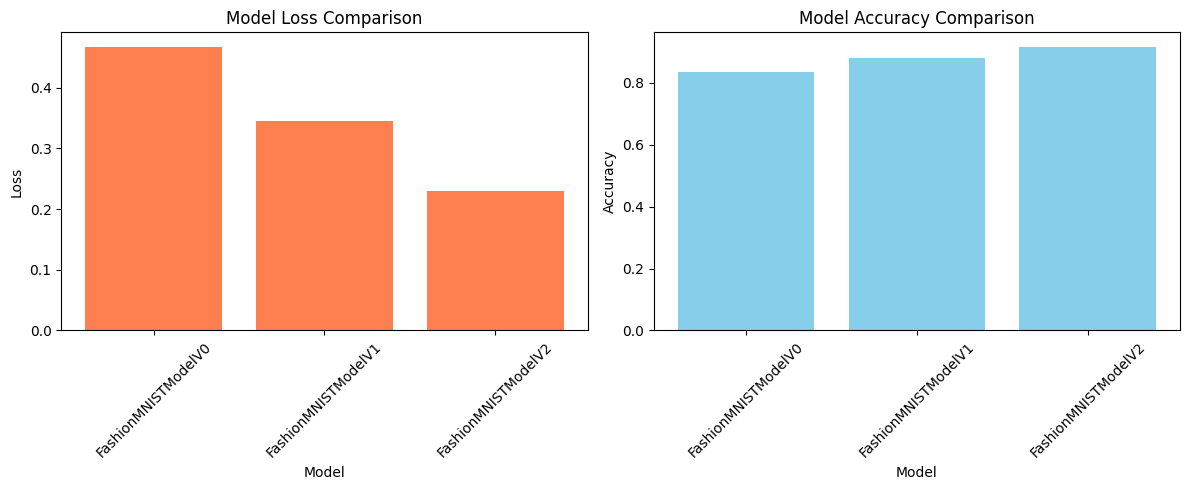

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(results_df["model_name"], results_df["model_loss"], color="coral")
ax1.set_xlabel("Model")
ax1.set_ylabel("Loss")
ax1.set_title("Model Loss Comparison")
ax1.tick_params(axis="x", rotation=45)

ax2.bar(results_df["model_name"], results_df["model_accuracy"], color="skyblue")
ax2.set_xlabel("Model")
ax2.set_ylabel("Accuracy")
ax2.set_title("Model Accuracy Comparison")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Make and evaluate random predictions with the best model

In [ ]:
def make_predictions(model: nn.Module, data: list, device: torch.device) -> list:
  preds = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)

      pred_logits = model(sample)

      pred_probs = torch.softmax(pred_logits, dim=1)

      pred_labels = torch.argmax(pred_probs, dim=1).item()

      preds.append(pred_labels)

  return preds

In [ ]:
import random

test_samples = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append({
      "image": sample,
      "label": label
  })

sample = test_samples[0]
test_image = sample["image"].cpu()
test_label = sample["label"]


Text(0.5, 1.0, 'Dress')

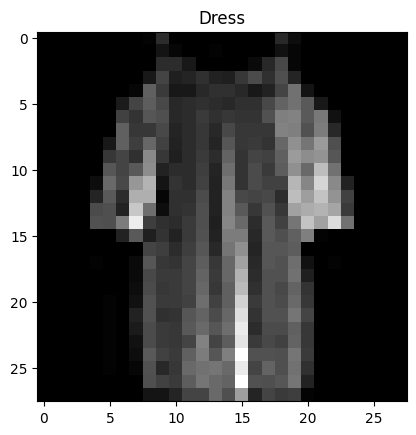

In [ ]:
plt.imshow(test_image.squeeze(), cmap="gray")
plt.title(class_names[test_label])

In [ ]:
# Make predictions
test_images = [samp["image"] for samp in test_samples]
test_labels = [samp["label"] for samp in test_samples]

preds = make_predictions(model_2, data=test_images, device=config.device)

test_labels, preds

([3, 7, 8, 6, 8, 7, 4, 0, 2], [3, 7, 8, 3, 8, 7, 4, 0, 2])

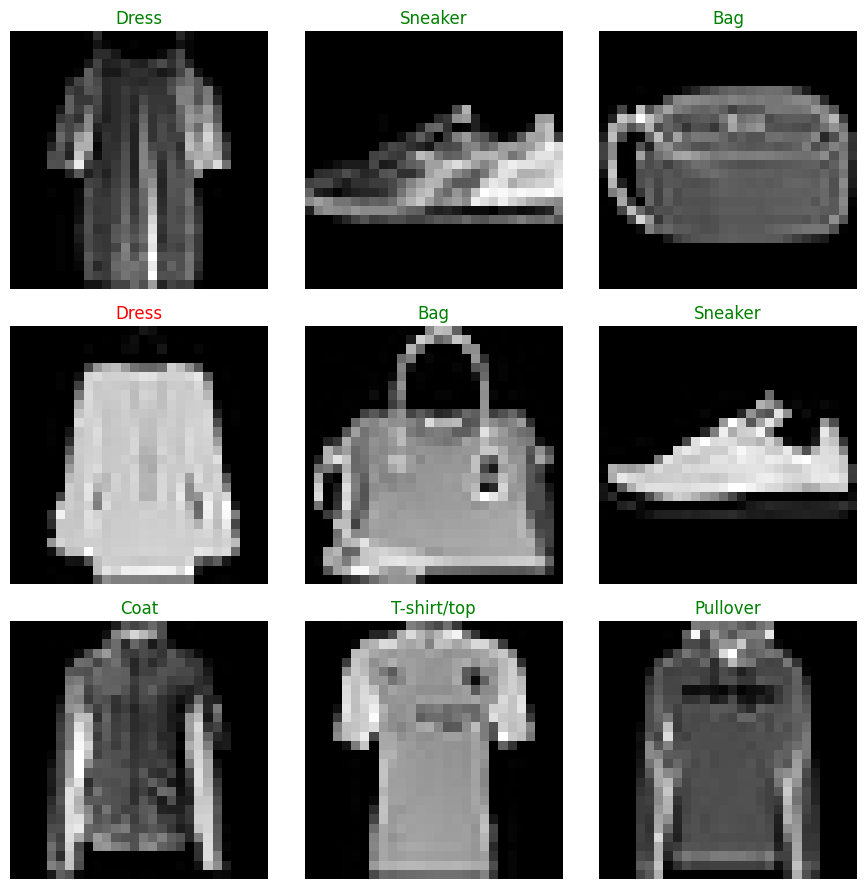

In [ ]:
# Plot predictions

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
  img = test_images[i]
  pred_lbl = preds[i]
  true_lbl = test_labels[i]

  ax.imshow(img.squeeze(), cmap="gray")
  ax.axis(False)
  ax.set_title(class_names[pred_lbl], color='red' if pred_lbl != true_lbl else 'green')

plt.tight_layout()

## Making a Confusion Matrix to evaluate our model

In [ ]:
import mlxtend

In [ ]:
# Making predictions with our trained model

y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader):
    X = X.to(device)
    y = y.to(device)

    y_logits = model_2(X)
    y_probs = torch.softmax(y_logits, dim=1)
    predictions = torch.argmax(y_probs, dim=1)

    y_preds.append(predictions.cpu())

y_preds = torch.concat(y_preds, dim=0)
y_preds[:10], y_preds.shape

  0%|          | 0/313 [00:00<?, ?it/s]

(tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]), torch.Size([10000]))

In [ ]:
import mlxtend

In [ ]:
mlxtend.__version__

'0.23.4'

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

In [ ]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
# Confusion Matrix instance and comparison of preds and targets
confmat = ConfusionMatrix(task='multiclass', num_classes=len(class_names))
confmat_tensor = confmat(preds=y_preds, target=test_data.targets)

In [ ]:
# Plot the Confusion Matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.cpu().numpy(),
    class_names=class_names,
    figsize=(10, 7)
  )

## Saving and loading our best performing model

In [ ]:
from pathlib import Path

model_path = Path("models")
model_path.mkdir(parents=True, exist_ok=True)

model_name = f"{model_2.__class__.__name__}.pth"

full_save_path = model_path / model_name
full_save_path

PosixPath('models/FashionMNISTModelV2.pth')

In [ ]:
torch.save(obj=model_2.state_dict(), f=full_save_path)

In [ ]:
loaded_model = FashionMNISTModelV2(
    input_shape=1,
    output_shape=len(class_names),
    hidden_units=32,
    device=config.device
)

loaded_state_dict = torch.load(full_save_path)

loaded_model.load_state_dict(loaded_state_dict)

<All keys matched successfully>

In [ ]:
def compare_state_dicts(m1: nn.Module, m2: nn.Module) -> bool:
  sd1 = m1.state_dict()
  sd2 = m2.state_dict()

  if sd1.keys() != sd2.keys():
    return False

  for k in sd1:
    if not torch.equal(sd1[k], sd2[k]):
      return False

  return True

compare_state_dicts(model_2, loaded_model)

True

In [ ]:
loaded_model_results = eval_model(loaded_model, test_dataloader, loss_fn, accuracy_fn, config.device)
loaded_model_results, model_2_results

({'model_name': 'FashionMNISTModelV2',
  'model_loss': 0.27717001995625207,
  'model_accuracy': 0.899399995803833},
 {'model_name': 'FashionMNISTModelV2',
  'model_loss': 0.27717001995625207,
  'model_accuracy': 0.899399995803833})